# Citation paper classification with cora

prebuild dataset - cora
these paper contains specific research papers and citation relationships btn those papers

we represent dataset as graphs


Package installation

pytorch lib - Planetoid ( datasets can be imported using this )


Name | #nodes | #edges | #features | #classes

Cora | 2,708 | 10,556 | 1,433 | 7


In [1]:
# & "C:\Users\YASHASH RAVI\AppData\Local\Programs\Python\Python311\python.exe" -m pip install torch torch-geometric scikit-learn pandas networkx
# & "C:\Users\YASHASH RAVI\AppData\Local\Programs\Python\Python311\python.exe" -m pip install torch-geometric

import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
from torch_geometric.datasets import Planetoid

# load cora citation graph

Planetoid is the PyTorch Geometric dataset wrapper for Cora, CiteSeer, and PubMed [4]. Each paper is a node, each citation is an
edge,
x contains node features, and
y contains topic labels. The provided masks define the train, validation, and test nodes.


In [3]:
dataset = Planetoid(root="data/Planetoid", name="cora")

In [4]:
dataset
# cora()

data = dataset[0]
print(data)
# Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

# so here x = [2708, 1433] - [nodes,features]

# nodes / papers
print(data.num_nodes)

# citation
print(data.num_edges)

# features
print(data.num_node_features)

# topics
print(dataset.num_classes)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
2708
10556
1433
7


In [ ]:
# dataset.label

# Case Based
# Genetic Algorithms
# Neural Networks
# Probabilistic Methods
# Reinforcement Learning
# Rule Learning
# Theory

AttributeError: 'Planetoid' object has no attribute 'label'

In [6]:
# training
# Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

print(data.train_mask.sum())
print(data.val_mask.sum())
print(data.test_mask.sum())

tensor(140)
tensor(500)
tensor(1000)


how does the nodes connectes to each pther

if a is cnnected to 4 other nodes then -> (degree of A = 4)


# check data Balancing


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
0    351
1    217
2    418
3    818
4    426
5    298
6    180
Name: count, dtype: int64


<Axes: xlabel='None', ylabel='count'>

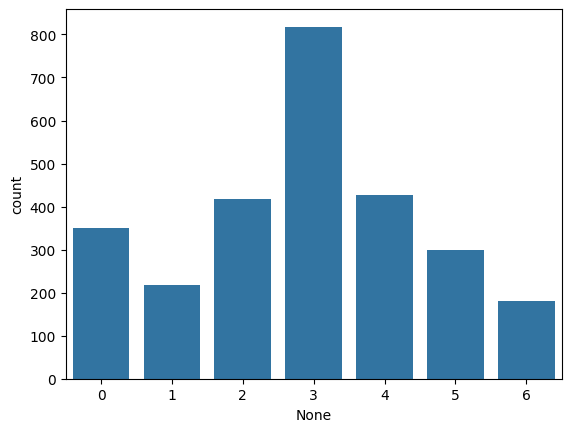

In [7]:
print(data)

# y = data.y
# tenser data
# convert tenser data to numpy

topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()
print(topic_counts)
# labels - 7
topic_index = topic_counts.index
topic_index


sns.barplot(x=topic_index, y=topic_counts)

# ai generated graph visualize for topic trail


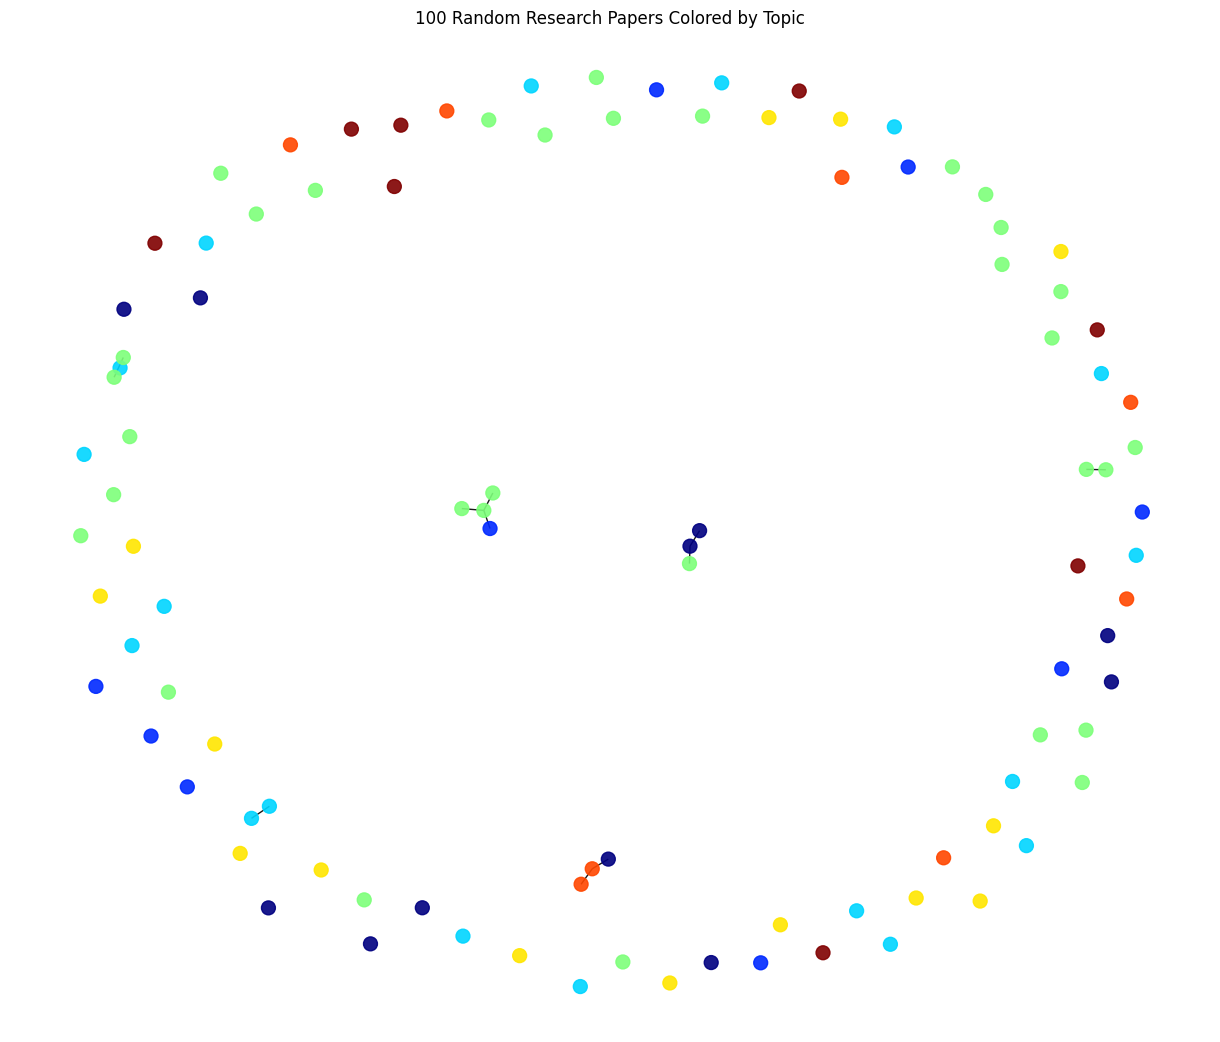

In [8]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt

SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [data.y[node].item() for node in sample_graph.nodes()]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False,
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

# Baseline: TF-IDF-style features plus Random ForestBaseline: TF-IDF-style features plus Random Forest


In [9]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [10]:
# Reweight the supplies word indicators. - TF-Idf

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf  # Features


# x and y splitting

train_idx = data.train_mask.numpy()  # Training Research Papers
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx], y[test_idx]

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluations


In [11]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

rf_accuracy = accuracy_score(y_test,rf_pred)
rf_f1_score = f1_score(y_test,rf_pred,average='macro')

print(f"accuracy score :- {accuracy_score(y_test,rf_pred):.4f}")
print(f"f1 score :- {f1_score(y_test,rf_pred,average='macro'):.4f}")

accuracy score :- 0.5800
f1 score :- 0.5818


<Axes: >

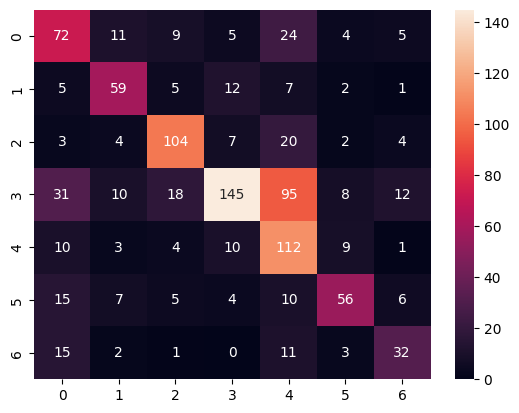

In [12]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")

# advance model - simple 2 layer GCN

2 layers - relu , drop out


In [13]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch


# create own model
class SimpleGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.convo1 = GCNConv(input_dim, hidden_dim)
        self.convo2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    # feed forward pass
    def forward(self, x, edge_index):
        x = self.convo1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convo2(x, edge_index)

        return x


model = SimpleGCN(
    input_dim=data.num_node_features, hidden_dim=32, output_dim=dataset.num_classes
)


# apply adam aptimizer to model
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


print(model)

SimpleGCN(
  (convo1): GCNConv(1433, 32)
  (convo2): GCNConv(32, 7)
)


Training of GCN model


In [14]:
# working of one epochs
def train_one_epoc():
    model.train()  # training started model
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    # to get numpy object - instead of tensor
    return loss.item()

# Evaluation Funtion


In [15]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

# Own evaluation matrix

pred

accuracy

f1 score


In [16]:
@torch.no_grad()  # no grad should be stored
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    predictions = logits.argmax(dim=1)  # find higest score in each research apaper
    accuracy = (
        (predictions[mask] == data.y[mask]).float().mean().item()
    )  # get avg accuracy
    micro_f11 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro",
    )

    return accuracy, micro_f11, predictions

In [17]:
evaluate(data.train_mask)

# training_accuracy,_,_ = evaluate(data.train_mask) - get only accuracy
training_accuracy, _, _ = evaluate(data.train_mask)
validation_accuracy, _, _ = evaluate(data.val_mask)
training_accuracy
validation_accuracy

0.11599999666213989

In [18]:
losses, train_accuracies, val_accuracies = [], [], []
best_validation_accuracy = 0.0
best_state = None


epochs_wihout_improvement = 0
patience = 20 # stop trianing after 20 epochs if there is no improvements

for epoch in range(1, 201):
    loss = train_one_epoc()
    train_acc, _, _ = evaluate(data.train_mask)
    val_acc, _, _ = evaluate(data.val_mask)

    losses.append(loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_validation_accuracy:
        best_validation_accuracy = val_acc
        best_state = model.state_dict()
        epochs_wihout_improvement = 0
    
    else:
        epochs_wihout_improvement += 1

    # print on each 10 epochs
    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch: {epoch:03d} | Loss: {loss:.4f} | "
            f"Train accuracy: {train_acc:.4f} | Validation accuracy: {val_acc:.4f}"
        )

    if epochs_wihout_improvement >= patience:
        print(f"early stopping at epoch : {epoch}")
        break
    
if best_state is not None:
    model.load_state_dict(best_state)

gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\n\nGCN text accuracy : {gcn_accuracy:.4f}")
print(f"GCN text macro-f1 : {gcn_f1:.4f}")

Epoch: 001 | Loss: 1.9525 | Train accuracy: 0.7786 | Validation accuracy: 0.4360
Epoch: 010 | Loss: 0.4267 | Train accuracy: 0.9857 | Validation accuracy: 0.7820
Epoch: 020 | Loss: 0.0500 | Train accuracy: 1.0000 | Validation accuracy: 0.7780
Epoch: 030 | Loss: 0.0135 | Train accuracy: 1.0000 | Validation accuracy: 0.7640
early stopping at epoch : 33


GCN text accuracy : 0.7820
GCN text macro-f1 : 0.7774


In [19]:
best_state

OrderedDict([('convo1.bias',
              tensor([0.1666, 0.1333, 0.1370, 0.1223, 0.1851, 0.1206, 0.0594, 0.1750, 0.0974,
                      0.1422, 0.1705, 0.1138, 0.1716, 0.1269, 0.0856, 0.1274, 0.1713, 0.1148,
                      0.0695, 0.1363, 0.1525, 0.0957, 0.1913, 0.1881, 0.1329, 0.1519, 0.0916,
                      0.1004, 0.1375, 0.1347, 0.0843, 0.1026])),
             ('convo1.lin.weight',
              tensor([[ 0.0502,  0.1718,  0.0828,  ...,  0.0372, -0.0429,  0.1801],
                      [-0.0273, -0.1977,  0.1234,  ..., -0.0976, -0.0925, -0.1386],
                      [-0.0930,  0.0056, -0.1545,  ...,  0.1112,  0.0808,  0.1447],
                      ...,
                      [-0.0440,  0.1909, -0.1414,  ...,  0.1737,  0.1713,  0.2255],
                      [ 0.0143, -0.0995,  0.0147,  ..., -0.0346,  0.0465, -0.0544],
                      [-0.1356, -0.1868, -0.0185,  ..., -0.1154,  0.0486, -0.1597]])),
             ('convo2.bias',
              tensor([-0.2

<Axes: >

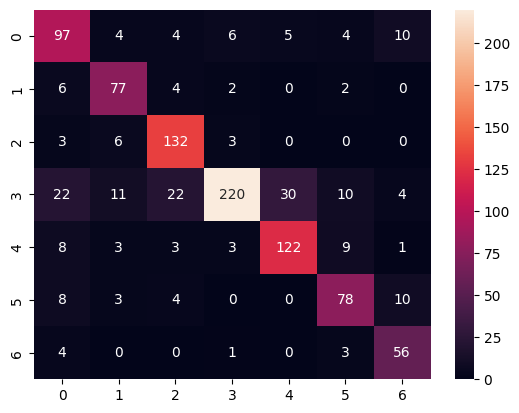

In [20]:
# confustion matrix for gcn model
sns.heatmap(confusion_matrix(data.y[data.test_mask].numpy(),gcn_pred[data.test_mask].numpy()),annot=True,fmt="d")

# comapring the model

random forest - 

GCN - 

In [21]:
results = pd.DataFrame({
    "Model":["Random Forest","GCN"],
    "Accuracy": [rf_accuracy,gcn_accuracy],
    "Macro f1 score": [rf_f1_score,gcn_f1]
})
results

,Model,Accuracy,Macro f1 score
0,Random Forest,0.580,0.581814
1,GCN,0.782,0.777353


so here gcn finds the connection - of neighbpuring information 

# saving the model

ONNX - open nural network exchange

IT IS FAST AND OPTIMISED - 

In [29]:
import torch

# % pip install onnxscript ----- install it in env - python 11.9

#  set the model to evaluation mode
model.eval()

# crate dummy input for onnx export
# the input x has shaped [num_nodes,num_features]
# the input 'edge_index' has shape [2,num_features]
x_dummy = data.x
edge_index_dummy = data.edge_index


# 1.  trained model
# 2.  model inout
# 3.  saving location / name
# 4.  store the trained parameters wts inside model file
# 5.  chnaged opset_version to 18 to avoid version conversion issues
# 6.  weather to exe contraint folding for optimization
# 7.  input names
# 8.  ouput names
# 9.  variable len for num_nodes
# 10. variable len for num_edge


onnx_file_path = "Artifacts/simple_gcn_cora.onnx"

torch.onnx.export(
    model,
    (x_dummy, edge_index_dummy),
    onnx_file_path,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["node_features", "edge_indices"],
    output_names=["logits"],
    dynamic_axes={
        "node_features": {0: "num_nodes"},
        "edge_indices": {1: "num_edges"}
    },
)

print(f"model exported to {onnx_file_path}")

C:\Users\YASHASH RAVI\AppData\Local\Temp\ipykernel_44856\1814648604.py:29: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
model exported to Artifacts/simple_gcn_cora.onnx
